# BigMart Sales Prediction

### Import Needed Libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures

import joblib

from sklearn import metrics

from warnings import filterwarnings
filterwarnings('ignore')

### Data Collection and Processing

- dataset link : https://statso.io/2023/01/02/food-delivery-time-prediction-case-study/


In [157]:
#Read the data
df = pd.read_csv(r'C:\Users\mayur\Desktop\digit\assignments\data\deliverytime.csv')

In [158]:
#See first 10 rows
df.head(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30
5,9BB4,HYDRES09DEL03,22,4.8,17.431668,78.408321,17.461668,78.438321,Buffet,motorcycle,26
6,95B4,RANCHIRES15DEL01,33,4.7,23.369746,85.339820,23.479746,85.449820,Meal,scooter,40
7,9EB2,MYSRES15DEL02,35,4.6,12.352058,76.606650,12.482058,76.736650,Meal,motorcycle,32
8,1102,HYDRES05DEL02,22,4.8,17.433809,78.386744,17.563809,78.516744,Buffet,motorcycle,34
9,CDCD,DEHRES17DEL01,36,4.2,30.327968,78.046106,30.397968,78.116106,Snack,motorcycle,46


In [159]:
#print number of rows and columns separately

print("Number of Rows:",df.shape[0])
print("Number of Features:",df.shape[1])


Number of Rows: 45593
Number of Features: 11


In [160]:
#see dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [161]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Time_taken(min)']

We have 4 categorical features : ['ID', 'Delivery_person_ID', 'Type_of_order', 'Type_of_vehicle']


In [162]:
#Check for missing values
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

### Data Analysis

In [163]:
#See descriptive statistics of numerical columns
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


### Data Visualization of Numerical Features

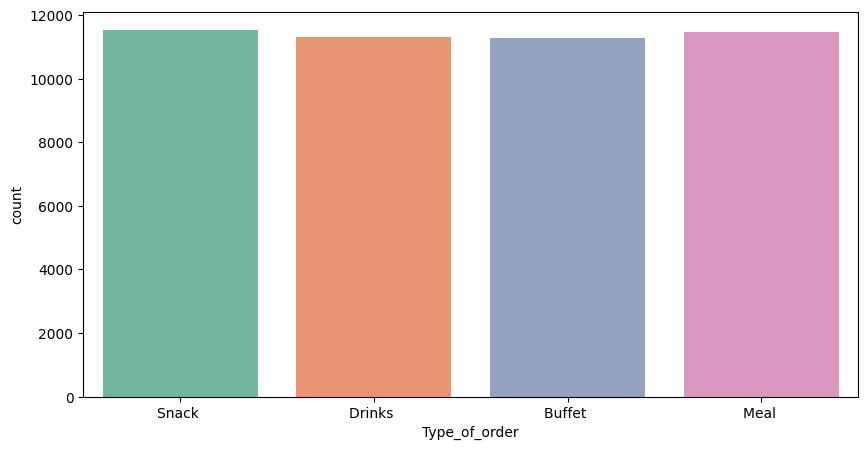

In [164]:
#Plot countplot for Outlet_Establishment_Year column
plt.figure(figsize=(10,5))
sns.countplot(x='Type_of_order', data=df, palette='Set2')
plt.show()

### Data Visualization of Categorical Features

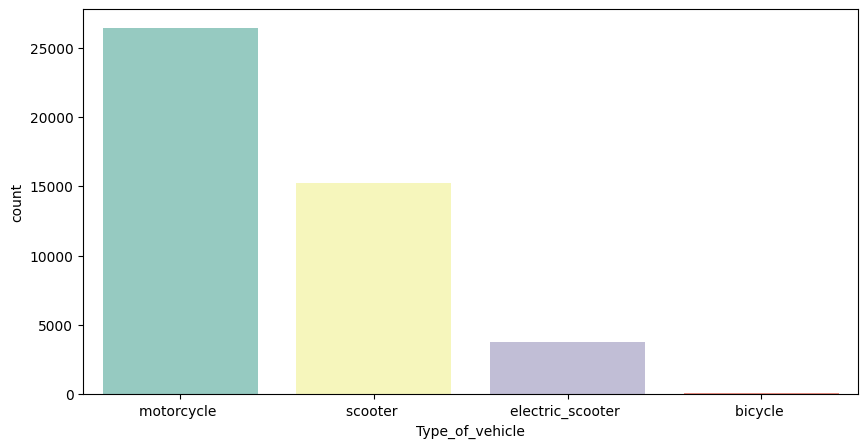

In [165]:
#Plot countplot for Item_Fat_Content column
plt.figure(figsize=(10,5))
sns.countplot(x= 'Type_of_vehicle' , data=df, palette='Set3')
plt.show()

### Data Preprocessing

In [166]:
#see categories in Item_Fat_Content column
df['Type_of_vehicle'].value_counts()

Type_of_vehicle
motorcycle           26435
scooter              15276
electric_scooter      3814
bicycle                 68
Name: count, dtype: int64

In [167]:
#see categories in Item_Fat_Content column
df['Type_of_order'].value_counts()

Type_of_order
Snack      11533
Meal       11458
Drinks     11322
Buffet     11280
Name: count, dtype: int64

### Seperate Features from Label

In [168]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30
...,...,...,...,...,...,...,...,...,...,...,...
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32
45589,D641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle,36
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26


In [169]:
#sepertate features and target

X = df.iloc[:, 2:-1]

y = df.iloc[:, -1]

In [170]:
# from sklearn.preprocessing import OneHotEncoder
# import pandas as pd

# # Select categorical columns (last 2 in X)
# categorical_cols = X.columns[-2:]

# # One-hot encode
# encoder = OneHotEncoder(sparse_output=False)
# encoded_array = encoder.fit_transform(X[categorical_cols])

# # Save encoder for later use
# joblib.dump(encoder, "onehot_encoder.pkl")

# # Create DataFrame for encoded features
# encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols), index=X.index)

# # Merge encoded with the rest of X
# X_encoded = pd.concat([X.drop(columns=categorical_cols), encoded_df], axis=1)

# X_encoded.head()



In [171]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib

categorical_cols = ['Type_of_order', 'Type_of_vehicle']
numeric_cols = X.columns[:-2]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# ✅ Fit first
X_encoded = preprocessor.fit_transform(X)

# ✅ Then save fitted version
joblib.dump(preprocessor, "onehot_encoder.pkl")


['onehot_encoder.pkl']

In [172]:
X

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter
...,...,...,...,...,...,...,...,...
45588,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle
45589,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle
45590,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter
45591,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle


In [173]:
y

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: Time_taken(min), Length: 45593, dtype: int64

### Split data into train and test sets

In [174]:
#splittting data into training and testing data
X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42)

In [175]:
#print shape of features and training and testing data of features
print("Shape of Features:", X_encoded.shape)
print("Shape of Features_train:", X_train.shape)
print("Shape of Features_test:", X_test.shape)

Shape of Features: (45593, 14)
Shape of Features_train: (36474, 14)
Shape of Features_test: (9119, 14)


In [176]:
#print shape of Target and training and testing data of Target
print("Shape of Target:", y.shape)
print("Shape of Target_train:", y_train.shape)
print("Shape of Target_test:", y_test.shape)

Shape of Target: (45593,)
Shape of Target_train: (36474,)
Shape of Target_test: (9119,)


### Building Model


In [177]:
models_r2_score = {
    "Multiple Linear Regression": None,
    "Decision Tree Regressor": None,
    "Random Forest Regressor": None,
    "XGBoost Regressor": None,
    "Support Vector Regressor": None
}

#### Multiple Linear Regression

In [178]:
# ---------- 1. Multiple Linear Regression ----------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
Target_pred = lr_model.predict(X_test)

#calculate R-Squared
r2_score = metrics.r2_score(y_test,Target_pred)
print("R-Squared:",r2_score)
models_r2_score["Multiple Linear Regression"] = [lr_model, round(r2_score,4)]

#calculate Mean Absolute Error
mae = metrics.mean_absolute_error(y_test,Target_pred)
print("Mean Absolute Error:",mae)

#calculate Mean Squared Error
mse = metrics.mean_squared_error(y_test,Target_pred)
print("Mean Squared Error:",mse)

R-Squared: 0.2025663899852128
Mean Absolute Error: 6.610261922403658
Mean Squared Error: 69.91749309101607


#### Decision Trees Regressor

In [179]:
# ---------- 3. Random Forest Regressor ----------
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
pred_dt = dt_model.predict(X_test)

#calculate R-Squared
r2_score = metrics.r2_score(y_test,pred_dt)
print("R-Squared:",r2_score)
models_r2_score["Decision Tree Regressor"] = [dt_model, round(r2_score,4)]

#calculate Mean Absolute Error
mae = metrics.mean_absolute_error(y_test,pred_dt)
print("Mean Absolute Error:",mae)

#calculate Mean Squared Error
mse = metrics.mean_squared_error(y_test,pred_dt)
print("Mean Squared Error:",mse)

R-Squared: -0.3076877392254964
Mean Absolute Error: 8.258855137624739
Mean Squared Error: 114.65562439838676


#### Building  XGBRegressor Model

In [180]:
#build model with XGBRegressor
XGBRModel = XGBRegressor()
XGBRModel.fit(X_train,y_train)
Target_pred = XGBRModel.predict(X_test)

#calculate R-Squared
r2_score = metrics.r2_score(y_test,Target_pred)
print("R-Squared:",r2_score)
models_r2_score["XGBoost Regressor"] = [XGBRModel, round(r2_score,4)]

#calculate Mean Absolute Error
mae = metrics.mean_absolute_error(y_test,Target_pred)
print("Mean Absolute Error:",mae)

#calculate Mean Squared Error
mse = metrics.mean_squared_error(y_test,Target_pred)
print("Mean Squared Error:",mse)


R-Squared: 0.3633578419685364
Mean Absolute Error: 5.880324363708496
Mean Squared Error: 55.81959533691406


#### Building  SVR Model

In [181]:
#build model with SVR
svr_model = SVR()
svr_model.fit(X_train,y_train)
Target_pred = svr_model.predict(X_test)

#calculate R-Squared
r2_score = metrics.r2_score(y_test,Target_pred)
print("R-Squared:",r2_score)
models_r2_score["Support Vector Regressor"] =  [svr_model, round(r2_score,4)]

#calculate Mean Absolute Error
mae = metrics.mean_absolute_error(y_test,Target_pred)
print("Mean Absolute Error:",mae)

#calculate Mean Squared Error
mse = metrics.mean_squared_error(y_test,Target_pred)
print("Mean Squared Error:",mse)

R-Squared: 0.09558159730792126
Mean Absolute Error: 7.063095521685661
Mean Squared Error: 79.29772037127782


#### Building RandomForestRegressor Model

In [182]:
#build model with RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train,y_train)
Target_pred = rf_model.predict(X_test)

#calculate R-Squared
r2_score = metrics.r2_score(y_test,Target_pred)
print("R-Squared:",r2_score)
models_r2_score["Random Forest Regressor"] = [rf_model, round(r2_score,4)]


#calculate Mean Absolute Error
mae = metrics.mean_absolute_error(y_test,Target_pred)
print("Mean Absolute Error:",mae)

#calculate Mean Squared Error
mse = metrics.mean_squared_error(y_test,Target_pred)
print("Mean Squared Error:",mse)


R-Squared: 0.2938663754327807
Mean Absolute Error: 6.1566901583630385
Mean Squared Error: 61.91248048360688


#### Finding and saving best model

In [183]:
models_r2_score

{'Multiple Linear Regression': [LinearRegression(), 0.2026],
 'Decision Tree Regressor': [DecisionTreeRegressor(random_state=42), -0.3077],
 'Random Forest Regressor': [RandomForestRegressor(), 0.2939],
 'XGBoost Regressor': [XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
  0

In [185]:
import joblib

# Pick the best model based on R² score (index 1 of the list)
best_model_name = max(models_r2_score, key=lambda name: models_r2_score[name][1])

# Unpack the model and R² score
best_model, best_r2 = models_r2_score[best_model_name]

# Save only the trained model
joblib.dump(best_model, "best_model.pkl")

print(f"Best Model: {best_model_name} (R² = {best_r2:.4f}) saved as best_model.pkl")



Best Model: XGBoost Regressor (R² = 0.3634) saved as best_model.pkl


### Make a predictive System

In [188]:
# Preprocess the first 5 rows of your original data
X_sample = X.head(5)
y_sample = y.head(5)  # Assuming your target variable is stored in `y`

# Transform
X_sample_encoded = preprocessor.transform(X_sample)

# Predict
predictions = best_model.predict(X_sample_encoded)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual": y_sample.values,
    "Predicted": predictions
})

print(comparison_df)

   Actual  Predicted
0      24  25.257433
1      33  26.229984
2      26  24.313103
3      21  27.497864
4      30  23.848005


In [189]:
import pandas as pd
import joblib

# Load
best_model = joblib.load("best_model.pkl")
preprocessor = joblib.load("onehot_encoder.pkl")

# New input
new_data = [[37, 4.9, 22.745049, 75.892471, 22.765049, 75.912471, "Snack", "motorcycle"]]
cols = list(X.columns)  # Same order as training

new_df = pd.DataFrame(new_data, columns=cols)

# Preprocess
X_new_encoded = preprocessor.transform(new_df)

# Predict
prediction = best_model.predict(X_new_encoded)
print("Predicted value:", prediction[0])


Predicted value: 19.703367
